# Plot Figure 3E: Predicted survival

Plots model prediction of survival profile

This code is provided here for completeness only, full code containing model fitting and parameter inference is provided in complimentary [Github Repository](https://github.com/simonvanvliet/SpatialToleranceModel) 

In [1]:
import numpy as np
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import json

def uptake_diffusion_sinh(x, c0, L, A):
    """
    Calculates numerically stable uptake–diffusion concentration profile, assuming zero boundary condition at x=L.

    Parameters:
    - x: array-like, positions along the gradient
    - c0: float, maximum concentration at x=0
    - L: float, length of the domain
    - A: float, uptake/diffusion rate [1/m^2]

    Returns:
    - c: array-like, concentration at positions x
    c(x) = c0 * sinh(sqrt(A)*(L - x)) / sinh(sqrt(A)*L)

    """
    sA = np.sqrt(A)
    return c0 * np.sinh(sA * (L - x)) / np.sinh(sA * L)

def create_concentration_profile(df, x_vals):
    """
    Generate concentration profiles for all replicates at specified x positions.
    
    Parameters:
    - df: DataFrame containing fit parameters (c0, L, A) and unique_id
    - x_vals: array-like, positions along the gradient where concentrations are calculated
    
    Returns:
    - conc_profiles: DataFrame with columns 'unique_id', 'x', and 'concentration'
    """
    conc_profiles_list = []
    for _, row in df.iterrows():
        unique_id = row['unique_id']
        c0 = row['c0']
        L = row['L']
        A = row['A']
        c_x = uptake_diffusion_sinh(x_vals, c0, L, A)
        conc_profile = {
            'unique_id': unique_id,
            'y_um': x_vals,
            'concentration': c_x,
        }
        conc_profiles_list.append(conc_profile)

    conc_profiles = pd.DataFrame(conc_profiles_list).explode(['y_um', 'concentration']).reset_index(drop=True)
    return conc_profiles

def inv_logit(z):
    z = np.asarray(z, dtype=float)
    return 1.0 / (1.0 + np.exp(-z))

def predict_survival(conc_h, conc_r, model_params):
    """
    Predict survival probability given concentration and model parameters.
    
    Parameters:
    - conc_h: array-like, concentrations of hqno
    - conc_r: array-like, concentrations of rhl
    - model_params: dict, parameters of the logistic regression model with keys 'm_rhl', 'm_hqno', and 'b'
    
    Returns:`
    - survival_probs: array-like, predicted survival probabilities
    """

    m_rhl  = float(model_params["m_rhl"])
    m_hqno = float(model_params["m_hqno"])
    b      = float(model_params["b"])

    rz = m_rhl  * conc_r  + m_hqno * conc_h + b
    survival_probs = inv_logit(rz)
    
    return survival_probs

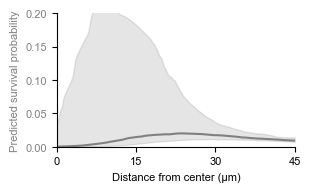

In [2]:
# ===========================================================
# Load parameters 
# ===========================================================

# Load model parameters
parameter_CSV = Path.cwd().parent.parent / 'model_fit_parameters' / 'full_model_parameters.csv'
df = pd.read_csv(parameter_CSV)
df['unique_id'] = df['replicate'].astype(str) + '_' + df['pos'].astype(str)

# Load parameters of fitted survival models
survival_model = Path.cwd().parent.parent / 'model_fit_parameters' / 'survival_model_parameters.json'
with open(survival_model, "r", encoding="utf-8") as f:
    logit_model = json.load(f)
# use parameters of the 'hqno_max_60' model as this fits the empirical concentration ranges best
model_params = logit_model['hqno_max_60']['parameters']


# get fitted rates
df_h = df[df['molecule'] == 'HQNO']
df_r = df[df['molecule'] == 'RHL']

# Generate high-resolution fitted curves for plotting
y_fit = np.linspace(0, 45, 181)
df_hqno = create_concentration_profile(df_h, y_fit)
df_rhl = create_concentration_profile(df_r, y_fit)


# --- Predict survival probabilities directly from measured concentrations ---
n_rep_h = len(df_hqno['unique_id'].unique())
n_rep_r = len(df_rhl['unique_id'].unique())
pred_survival = []


# Calculate survival probabilities using exhaustive empirical sampling of concentration profiles to estimate variability
for i in range(n_rep_h):
    for j in range(n_rep_r):
        conc_hqno = df_hqno[df_hqno['unique_id'] == df_hqno['unique_id'].unique()[i]][ 'concentration'].values
        conc_rhl = df_rhl[df_rhl['unique_id'] == df_rhl['unique_id'].unique()[j]][ 'concentration'].values

        y_hqno = df_hqno[df_hqno['unique_id'] == df_hqno['unique_id'].unique()[i]][ 'y_um'].values
        y_rhl = df_rhl[df_rhl['unique_id'] == df_rhl['unique_id'].unique()[j]][ 'y_um'].values

        if not np.array_equal(y_hqno, y_rhl) or len(y_hqno) == 0 or len(y_rhl) == 0:
            raise ValueError('y positions of hqno and rhl do not match!')

        survival_prob = predict_survival(conc_hqno, conc_rhl, model_params)

        output = {
            'hqno_id': df_hqno['unique_id'].unique()[i],
            'rhl_id': df_rhl['unique_id'].unique()[j],
            'unique_id': f"{df_hqno['unique_id'].unique()[i]}_{df_rhl['unique_id'].unique()[j]}",
            'y_um': y_hqno,
            'conc_hqno': conc_hqno,
            'conc_rhl': conc_rhl,
            'predicted_survival': survival_prob
        }

        pred_survival.append(output)

df_pred = pd.DataFrame(pred_survival).explode(['y_um', 'conc_hqno', 'conc_rhl', 'predicted_survival'])

final_width_in  = 8 / 2.54
final_height_in = 5 / 2.54
font_size = 8
plt.rcParams.update({
    'font.size': font_size,
    'font.family': 'Arial',
    'axes.labelsize': font_size,
    'axes.titlesize': font_size,
    'xtick.labelsize': font_size,
    'ytick.labelsize': font_size,
    'legend.fontsize': font_size,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

hqno_color = '#669966'
rhl_color  = '#cc99ff'

fig, ax = plt.subplots(figsize=(final_width_in, final_height_in))

ylabel = 'Predicted survival probability'
ylim = (0,0.2)
yticks = np.linspace(0, 0.2, 5)
color = 'grey'

perc = df_pred.groupby('y_um')['predicted_survival'].agg([
    ('lower',  lambda x: np.percentile(x.dropna(), 25)),
    ('median', lambda x: np.percentile(x.dropna(), 50)),
    ('upper',  lambda x: np.percentile(x.dropna(), 75)),
]).reset_index().sort_values('y_um')
ax.fill_between(perc['y_um'], perc['lower'], perc['upper'], alpha=0.2, color=color)
ax.plot(perc['y_um'], perc['median'], '-', lw=1.5, color=color)
ax.set_ylabel(ylabel, color=color, fontsize=font_size)
ax.tick_params(axis='y', labelcolor=color, labelsize=font_size)
ax.set_ylim(*ylim)
ax.set_yticks(yticks)

ax.set_xlabel("Distance from center (µm)", fontsize=font_size)
ax.set_xlim(0, 45)
ax.set_xticks([0, 15, 30, 45])
ax.tick_params(axis='x', labelsize=font_size)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()